# <font color=orange>Examen - Práctica 2</font>
## CUNEF - Inteligencia Artificial
### Múltiples oríngenes y destinos

---
---

## Descripción

Este examen tiene como objetivo que el alumno adapte su algoritmo **A\*** para trabajar con terrenos con múltiples puntos de entrada y múltiples puntos de salida, usando el framework **sIArena**.
Para ello se proponen varios casos de prueba basados en los mapas de la Práctica 2, modificando principalmente los orígenes y destinos.

La finalidad es probar las habilidades del alumno para generalizar el algoritmo previo a un nuevo escenario: en vez de buscar un único camino entre `terrain.origin` y `terrain.destination`, se debe encontrar el camino de menor coste entre cualquiera de los orígenes válidos y cualquiera de los destinos válidos.

### Requisitos del examen

Para este examen se debe utilizar el código entregado en la Práctica 2.
Solo se permite un código totalmente nuevo si la Práctica 2 no consiguió implementar el algoritmo correctamente.

### Entorno

Esta práctica se lleva a cabo en el entorno de trabajo **sIArena**, un proyecto open source alojado en Github.

- [Código fuente](https://github.com/jparisu/sIArena)
- [Documentación](https://siarena.readthedocs.io/en/latest/index.html)
- [Tutorial](https://siarena.readthedocs.io/en/latest/rst/getting_started/tutorial.html)

### Equipos de trabajo

El examen se realizará de forma individual.

### Entrega

La entrega se basará en este fichero Notebook con el código del algoritmo de path finding implementado por el alumno.

### Calificación

En la calificación se tendrá en cuenta con esta prioridad:

1. Ejecución del código sin errores.
2. Funcionamiento correcto del algoritmo.
3. Eficiencia en tiempo del algoritmo.
4. Elección y demostración de consistencia de la heurística.
5. Limpieza y claridad del código, comentarios y entrega.

Cualquier indicio de copia o plagio implicará la calificación de 0 en la práctica, y la posibilidad de abrir un expediente académico.
El profesor se reserva el derecho a pedir una defensa oral de la práctica para comprobar la autoría de la misma.

---

## Instrucciones del examen

Este examen se basa en un nuevo tipo de `Terrain`: `MultiEndpointTerrain`. Este terreno puede tener varios orígenes y varios destinos.

Un camino correcto debe cumplir estas condiciones:

1. Debe ser un camino válido: cada paso se mueve a una casilla vecina según la estructura del terreno.
2. Debe empezar en cualquiera de los orígenes devueltos por `terrain.get_origins()`.
3. Debe terminar en cualquiera de los destinos devueltos por `terrain.get_destinations()`.
4. No es necesario pasar por todos los orígenes ni por todos los destinos.

El objetivo del algoritmo es devolver el camino completo de menor coste entre cualquier par origen-destino posible.

### Entorno de trabajo

Se puede usar cualquier entorno de desarrollo, incluido Google Colab.

### Restricciones

Las **herramientas de IA** quedan totalmente prohibidas, a excepción del uso de la herramienta Gemini incluida en Google Colab.

Queda totalmente prohibido el uso de cualquier comunicación con terceros durante la realización del examen.


---
---

# Instalación de la librería sIArena

In [6]:
# INSTALL LIBRARY
import subprocess
import sys

SIARENA_BRANCH = "jparisu/multiendpoints"

# Check if installed
if "sIArena" in sys.modules:
    print("sIArena already installed.")
else:

    try:
        subprocess.check_call(["pip", "install", f"git+https://github.com/jparisu/sIArena.git@{SIARENA_BRANCH}"])
        print("sIArena Package installed.")

    except Exception as e:

        print(f"Error installing the package: {e}. Installing by magic command.")

        %pip install --upgrade git+https://github.com/jparisu/sIArena.git@main

sIArena already installed.


---
---

# Algoritmo de Path Finding

Aquí el alumno debe implementar el algoritmo de Path Finding.

🔨 **Este código debe ser terminado por el alumno**

❗ **No cambiar el nombre de la función principal**

In [13]:
from sIArena.terrain.Terrain import Coordinate, MultiEndpointTerrain, Path
import heapq # For the priority queue needed by A*

# Helper function to calculate Manhattan distance heuristic
def manhattan_distance_heuristic(current: Coordinate, destinations: set[Coordinate]) -> int:
    if not destinations:
        return 0 # No destinations, no cost to estimate
    return min(abs(current[0] - dest[0]) + abs(current[1] - dest[1]) for dest in destinations)

# Path finding algorithm
def path_finding(terrain: MultiEndpointTerrain) -> Path:
    origins = terrain.get_origins()
    destinations = terrain.get_destinations()

    # If there are no origins or no destinations, no path can be found
    if not origins or not destinations:
        return []

    # g_score: Cost from start to current node
    g_score = {o: 0 for o in origins}

    # f_score: Estimated total cost from start to goal through current node (g_score + heuristic)
    f_score = {o: manhattan_distance_heuristic(o, destinations) for o in origins}

    # Priority queue: stores (f_score, coordinate)
    # The lowest f_score is always popped first
    open_set = []
    for origin in origins:
        heapq.heappush(open_set, (f_score[origin], origin))

    # came_from: To reconstruct the path
    came_from = {}

    # Keep track of the best path found so far and its cost
    best_path_cost = float('inf')
    best_path = []

    # To store the g_score of any destination reached
    destination_g_scores = {}

    while open_set:
        current_f_score, current_coord = heapq.heappop(open_set)

        # If we have already found a shorter path to a destination, and the current f_score
        # is already greater than or equal to the best_path_cost, we can prune this branch.
        # This optimization is mainly for when we have already found a path and are looking for a better one.
        if current_f_score >= best_path_cost:
            continue

        # Check if the current node is a destination
        if current_coord in destinations:
            # A path to a destination has been found
            if g_score[current_coord] < best_path_cost:
                best_path_cost = g_score[current_coord]
                # Reconstruct path
                path = []
                node = current_coord
                while node in came_from:
                    path.append(node)
                    node = came_from[node]
                path.append(node) # Add the origin
                best_path = path[::-1] # Reverse to get path from origin to destination
            continue # Continue search for potentially shorter paths

        # Explore neighbors
        for neighbor in terrain.get_neighbors(current_coord):
            # Calculate tentative g_score for the neighbor
            cost_to_neighbor = terrain.get_cost(current_coord, neighbor)
            tentative_g_score = g_score.get(current_coord, float('inf')) + cost_to_neighbor

            # If this path to neighbor is better than any previous one
            if tentative_g_score < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current_coord
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + manhattan_distance_heuristic(neighbor, destinations)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return best_path

---
---

# Validador

En estas celdas se generan los casos de prueba y se mide la eficiencia del algoritmo implementado

⚠️ **No tocar estas celdas**

In [14]:
# DO NOT MODIFY
from sIArena.terrain.Terrain import MultiEndpointTerrain
from sIArena.terrain.generator.FocusedGenerator import FocusedGenerator
from sIArena.terrain.generator.PerlinGenerator import PerlinGenerator
from sIArena.terrain.generator.MazeGenerator import MazeGenerator

# Generate terrains construct parameters
parameters = {
    "empty  ": [PerlinGenerator(),  {"n":7,   "m":7,   "seed":43, "min_height":0, "max_height":0,    "min_step":1,   "abruptness":0,    "origin": {(4,0), (0,0), (6,6)},                "destination": {(6,1), (1,6), (3,3)},                   "terrain_ctor": MultiEndpointTerrain}],
    "dodge  ": [MazeGenerator(),    {"n":7,   "m":7,   "seed":43, "min_height":0, "max_height":0,    "min_step":1,   "abruptness":0,    "origin": (4,0),                                "destination": {(6,0), (1,2), (5,4)},                   "terrain_ctor": MultiEndpointTerrain}],
    "walk   ": [PerlinGenerator(),  {"n":20,  "m":20,  "seed":43, "min_height":0, "max_height":10,   "min_step":2,   "abruptness":0.1,  "origin": {(0,1), (4,0), (5,6)},                "destination": (16,15),                                 "terrain_ctor": MultiEndpointTerrain}],
    "fields ": [PerlinGenerator(),  {"n":100, "m":100, "seed":43, "min_height":0, "max_height":100,  "min_step":5,   "abruptness":0.1,  "origin": (0,0),                                "destination": (99,99),                                 "terrain_ctor": MultiEndpointTerrain}],
    "valleys": [PerlinGenerator(),  {"n":250, "m":250, "seed":43, "min_height":0, "max_height":100,  "min_step":5,   "abruptness":0.1,  "origin": {(1,1), (1,248), (248,1), (248,248)}, "destination": {(5,5), (5,245), (245,5), (245,245)},    "terrain_ctor": MultiEndpointTerrain}],
    "ocean  ": [FocusedGenerator(), {"n":200, "m":200, "seed":43, "min_height":0, "max_height":1000, "min_step":100, "abruptness":0.05, "origin": {(160,20), (175,20), (180,40)},       "destination": {(5,195), (45,160), (60,190), (10,150)}, "terrain_ctor": MultiEndpointTerrain}],
    "rafting": [PerlinGenerator(),  {"n":800, "m":800, "seed":43, "min_height":0, "max_height":1000, "min_step":10,  "abruptness":0.14, "origin": {(500,300), (520,280), (480,320)},    "destination": {(580,390), (600,370), (560,410)},       "terrain_ctor": MultiEndpointTerrain}],
}

# Generate terrains
terrains = {k: v[0].generate_random_terrain(**v[1]) for k,v in parameters.items()}

In [15]:
# DO NOT MODIFY
from sIArena.measurements.measurements import measure_function

results = {}
for terrain_name, terrain in terrains.items():
    min_cost, second, path = measure_function(path_finding, terrain, max_seconds=60)
    print(f"Terrain {terrain_name} has been solved in {second:.3f} seconds with a path of cost {min_cost}")

Terrain empty   has been solved in 0.000 seconds with a path of cost 3
Terrain dodge   has been solved in 0.001 seconds with a path of cost 5
Terrain walk    has been solved in 0.002 seconds with a path of cost 23
Terrain fields  has been solved in 0.057 seconds with a path of cost 271
Terrain valleys has been solved in 0.001 seconds with a path of cost 7
Terrain ocean   has been solved in 0.566 seconds with a path of cost 1690
Terrain rafting has been solved in 3.509 seconds with a path of cost 930


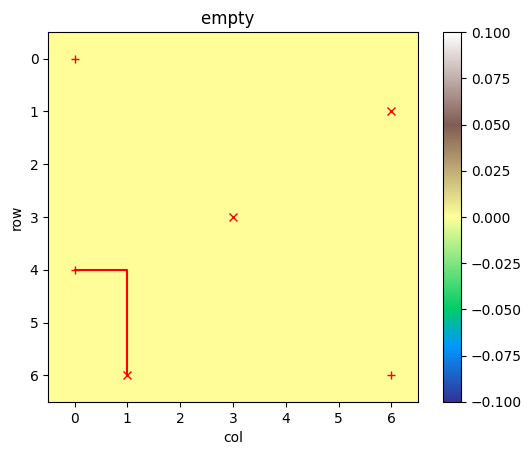

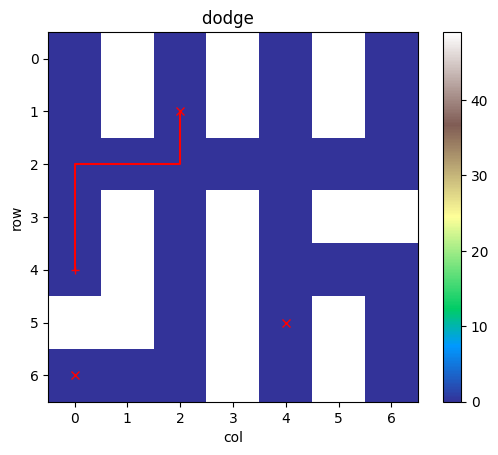

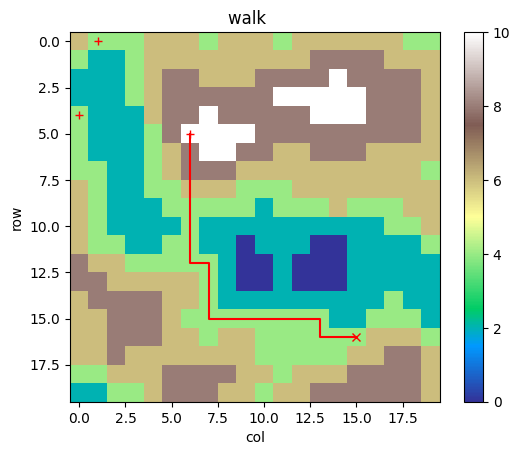

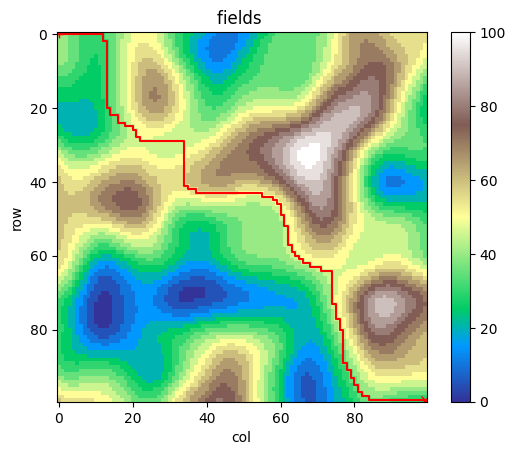

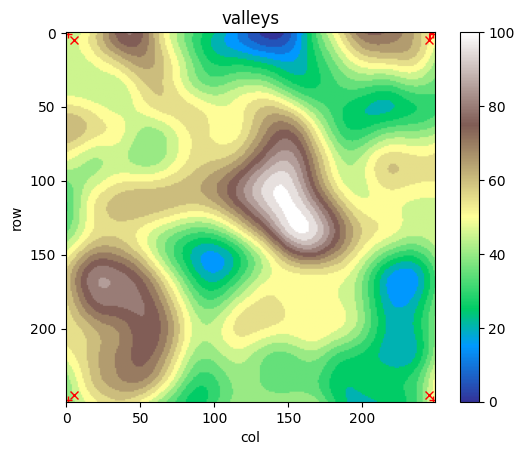

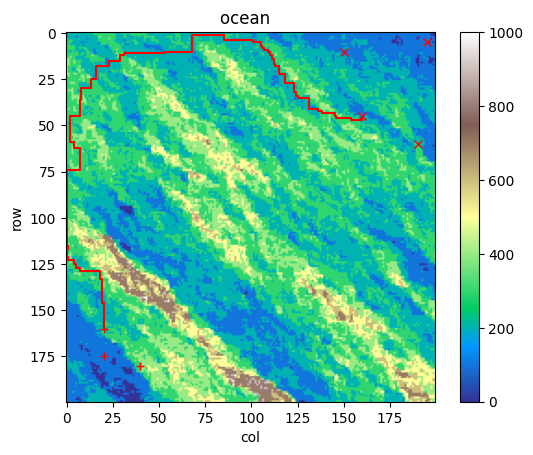

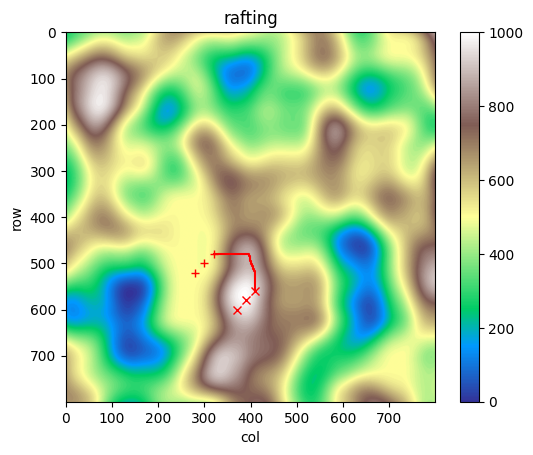

In [16]:
# EXECUTE TO SEE THE PLOTS
from sIArena.terrain.plot.plot_2D import plot_terrain_2D
for terrain_name, terrain in terrains.items():
    plot_terrain_2D(terrain, title=terrain_name, path=path_finding(terrain))